## Linear Regression

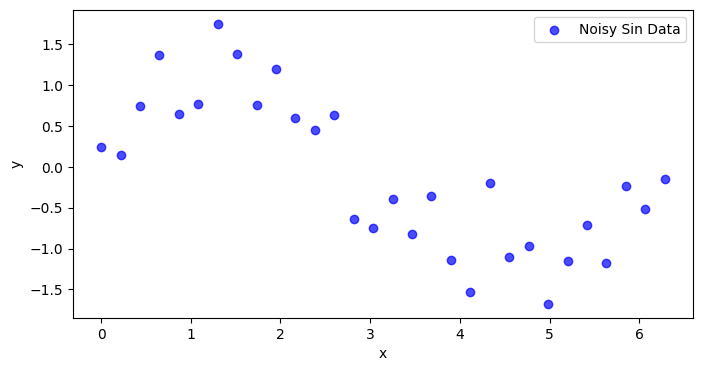

In [306]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_sin_data(n_samples=30, x_min=0, x_max=2*np.pi, noise_std=0.5, random_state=42):
    np.random.seed(random_state)
    x = np.linspace(x_min, x_max, n_samples)
    y = np.sin(x) + np.random.normal(0, noise_std, size=n_samples)
    
    df = pd.DataFrame({"x": np.round(x, 4), "y": np.round(y, 4)})
    return df

df = generate_sin_data()

x = df["x"].to_numpy()
y = df["y"].to_numpy()

plt.figure(figsize=(8, 4))
plt.scatter(x, y, color='blue', alpha=0.7, label='Noisy Sin Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

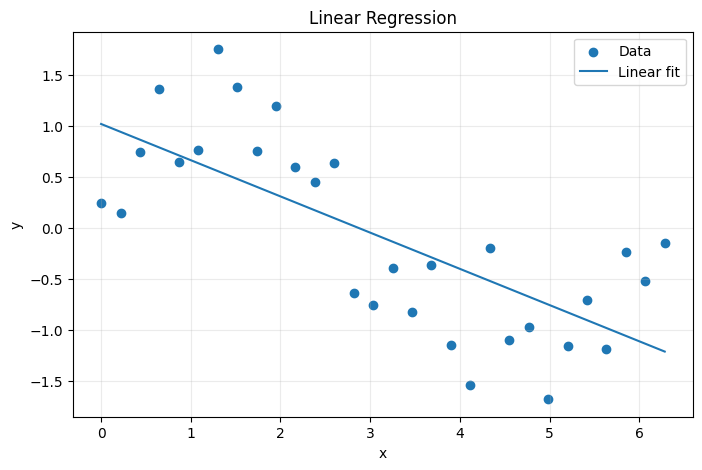

In [307]:
# Add the bias column x_0 = 1.
X = np.c_[np.ones(len(x)), x]

def normal_equation(X, y):
    # Normal equation:
    # theta = (X^T X)^-1 X^T y = X^+ y

    # theta = np.linalg.inv(X.T @ X) @ X.T @ y
    theta = np.linalg.pinv(X) @ y

    return theta

theta = normal_equation(X, y)

y_pred_linear = X @ theta

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred_linear, label="Linear fit")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Polynomial Regression 

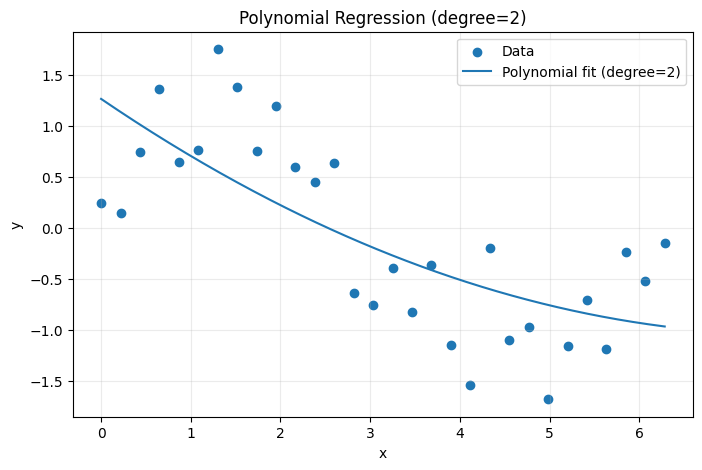

In [308]:
def polynomial_features(x, degree):
    """Return [1, x, x^2, ..., x^degree] for every sample."""

    X_poly = np.ones((len(x), degree + 1))

    for power in range(1, degree + 1):
        X_poly[:, power] = x ** power

    return X_poly


degree = 2

X_poly = polynomial_features(x, degree)

# Reuse exactly the same normal-equation function.
theta_poly = normal_equation(X_poly, y)

# my idea:
# y_pred_poly = X_poly @ theta_poly

# plt.figure(figsize=(8, 5))
# plt.scatter(x, y, label="Data")
# plt.plot(x, y_pred_poly, label=f"Polynomial fit (degree={degree})")

# plt.xlabel("x")
# plt.ylabel("y")
# plt.title(f"Polynomial Regression using the Normal Equation (degree={degree})")
# plt.legend()
# plt.grid(alpha=0.25)
# plt.show()

x_curve = np.linspace(x.min(), x.max(), 300)
X_curve = polynomial_features(x_curve, degree)
y_curve = X_curve @ theta_poly

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Data")
plt.plot(x_curve, y_curve, label=f"Polynomial fit (degree={degree})")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Polynomial Regression (degree={degree})")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Visualize ERMS

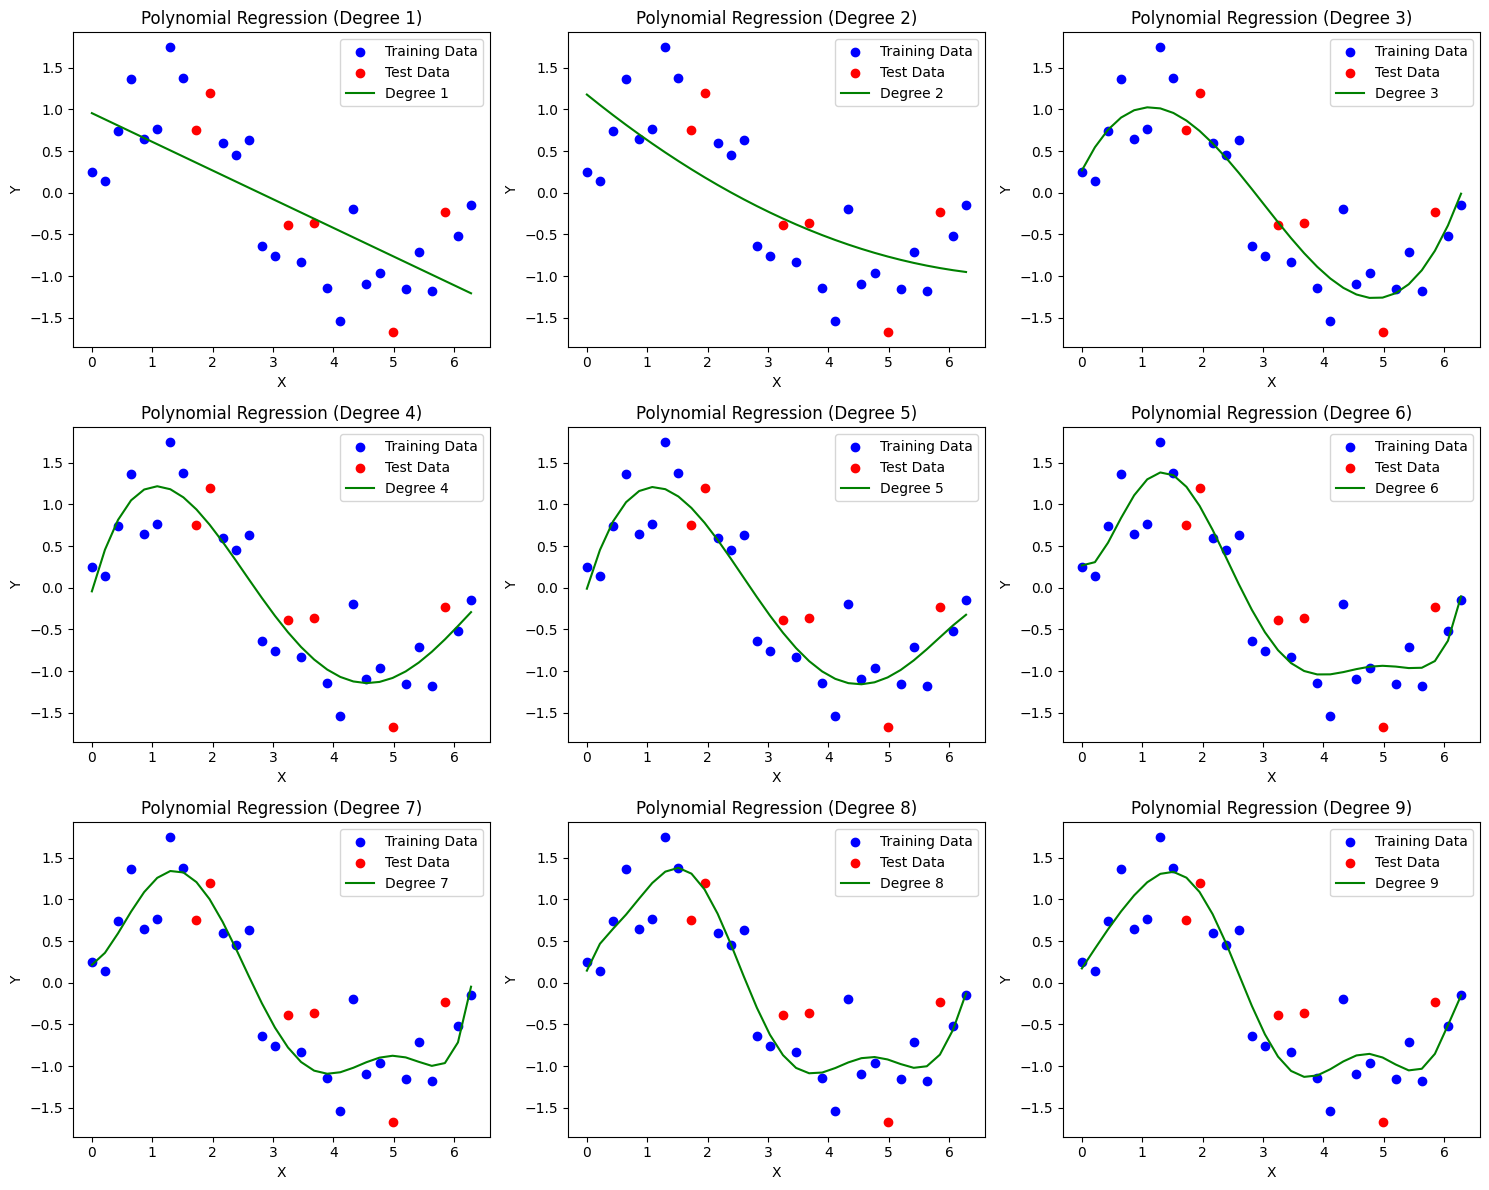

In [309]:
from sklearn.model_selection import train_test_split

# Define Root Mean Square Error compute function
def compute_rms_error(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

degrees = range(1, 10)
train_errors = []
test_errors = []

plt.figure(figsize=(15, 12))

for d in degrees:
    # Train the model and Make predictions on training set
    X_train_poly = polynomial_features(X_train, d)
    w_poly = normal_equation(X_train_poly, y_train)
    y_train_pred = X_train_poly @ w_poly

    # Make predictions on test set
    X_test_poly = polynomial_features(X_test, d)
    y_test_pred = X_test_poly @ w_poly

    # Compute RMSE
    train_rms_error = compute_rms_error(y_train, y_train_pred)
    test_rms_error = compute_rms_error(y_test, y_test_pred)

    # Store RMSE values
    train_errors.append(train_rms_error)
    test_errors.append(test_rms_error)

    X_poly = polynomial_features(x, d)
    y_poly = X_poly @ w_poly

    plt.subplot(3, 3, d)
    plt.scatter(X_train, y_train, color='blue', label="Training Data")
    plt.scatter(X_test, y_test, color='red', label="Test Data")
    plt.plot(x, y_poly, label=f"Degree {d}", color="green")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Polynomial Regression (Degree {d})")
    plt.legend()

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

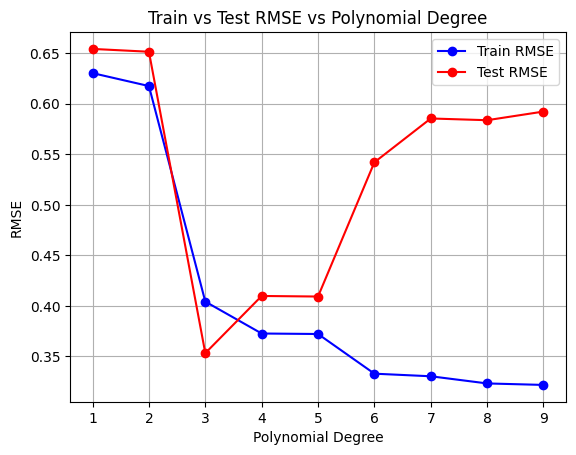

In [310]:
# Plot RMSE for training and test sets
plt.plot(degrees, train_errors, marker='o', color='blue', label='Train RMSE')
plt.plot(degrees, test_errors, marker='o', color='red', label='Test RMSE')
plt.title("Train vs Test RMSE vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.show()

## Another Example

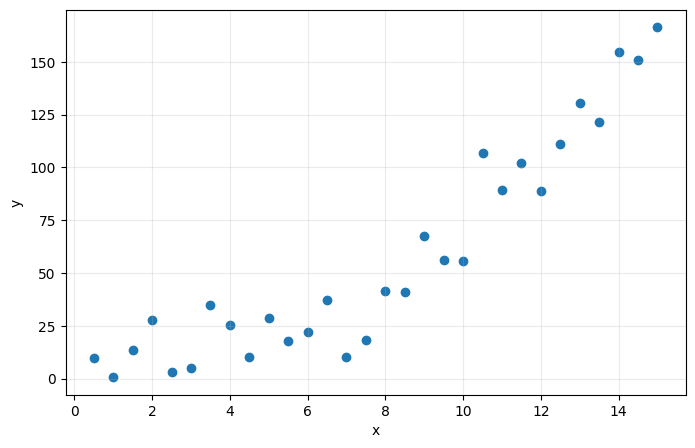

In [311]:
# Set seed for reproducibility
np.random.seed(42)

# Generate 30 non-linear data points
noise = 10
x = np.linspace(0.5, 15.0, 30)
y = 0.75 * (x**2) + 2.0 + np.random.normal(0, 1.5, size=30) * noise

plt.figure(figsize=(8, 5))
plt.scatter(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.25)
plt.show()

### Linear Regression

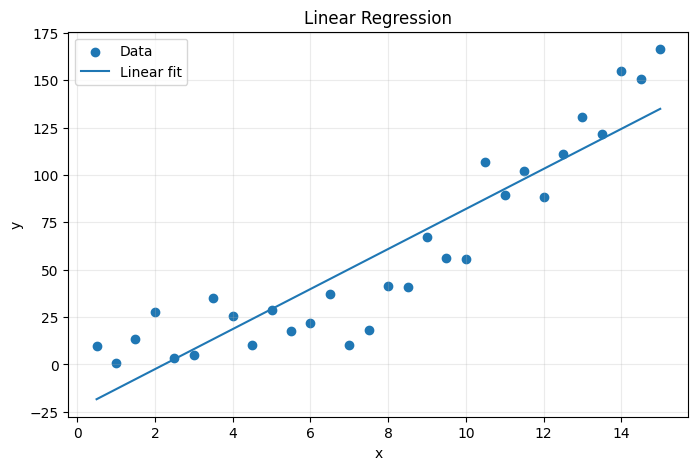

In [312]:
# Add the bias column x_0 = 1.
X = np.c_[np.ones(len(x)), x]

theta = normal_equation(X, y)

y_pred_linear = X @ theta

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred_linear, label="Linear fit")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Polynomial Regression

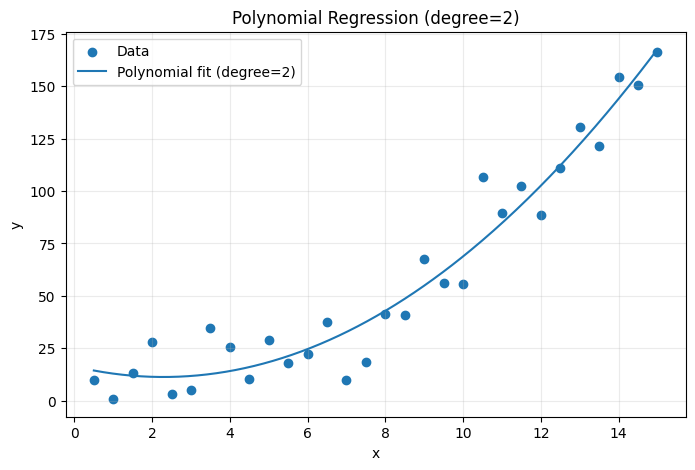

In [313]:
degree = 2

X_poly = polynomial_features(x, degree)

# Reuse exactly the same normal-equation function.
theta_poly = normal_equation(X_poly, y)

x_curve = np.linspace(x.min(), x.max(), 300)
X_curve = polynomial_features(x_curve, degree)
y_curve = X_curve @ theta_poly

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Data")
plt.plot(x_curve, y_curve, label=f"Polynomial fit (degree={degree})")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Polynomial Regression (degree={degree})")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### ERMS

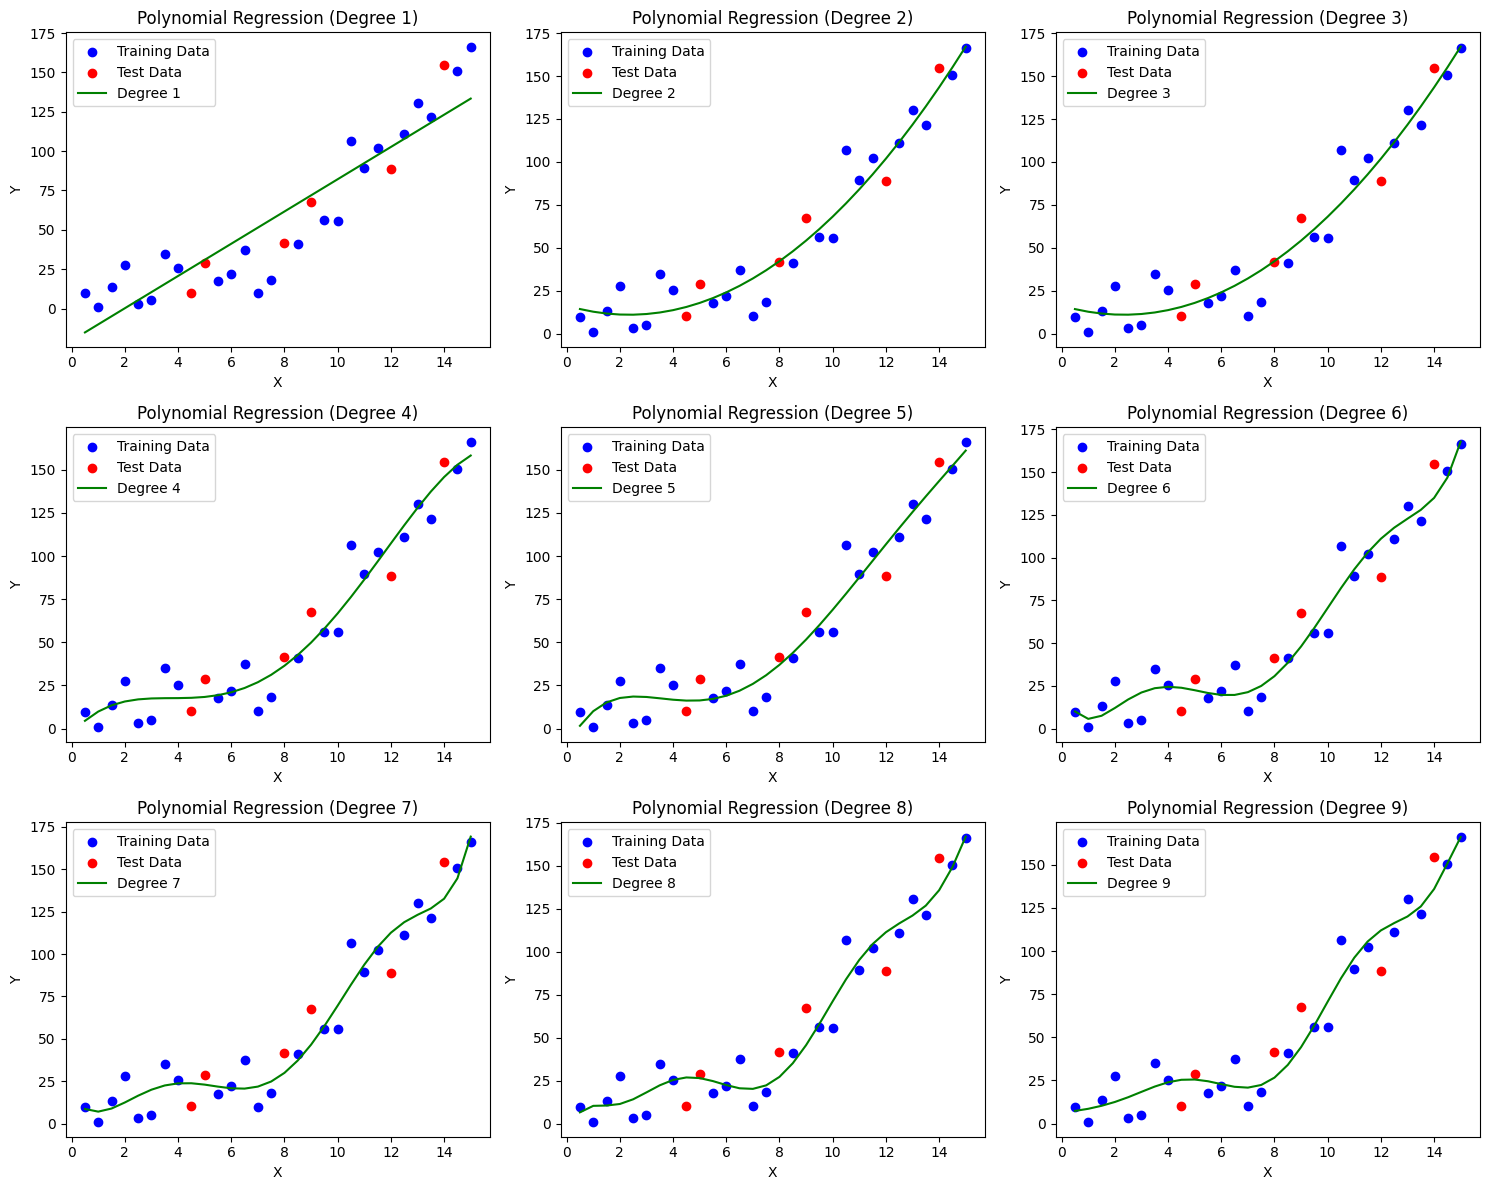

In [314]:
# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

degrees = range(1, 10)
train_errors = []
test_errors = []

plt.figure(figsize=(15, 12))

for d in degrees:
    # Train the model and Make predictions on training set
    X_train_poly = polynomial_features(X_train, d)
    w_poly = normal_equation(X_train_poly, y_train)
    y_train_pred = X_train_poly @ w_poly

    # Make predictions on test set
    X_test_poly = polynomial_features(X_test, d)
    y_test_pred = X_test_poly @ w_poly

    # Compute RMSE
    train_rms_error = compute_rms_error(y_train, y_train_pred)
    test_rms_error = compute_rms_error(y_test, y_test_pred)

    # Store RMSE values
    train_errors.append(train_rms_error)
    test_errors.append(test_rms_error)

    X_poly = polynomial_features(x, d)
    y_poly = X_poly @ w_poly

    plt.subplot(3, 3, d)
    plt.scatter(X_train, y_train, color='blue', label="Training Data")
    plt.scatter(X_test, y_test, color='red', label="Test Data")
    plt.plot(x, y_poly, label=f"Degree {d}", color="green")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Polynomial Regression (Degree {d})")
    plt.legend()

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

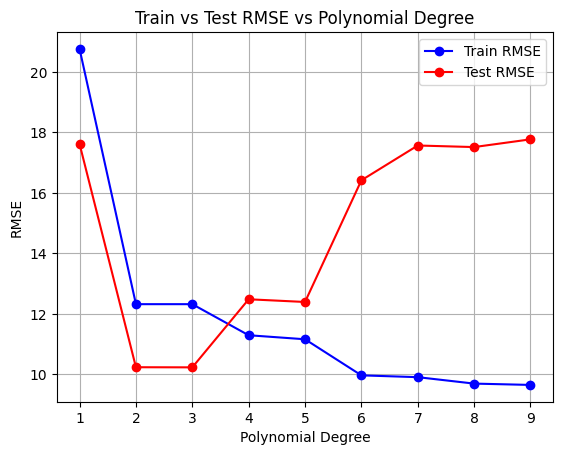

In [315]:
# Plot RMSE for training and test sets
plt.plot(degrees, train_errors, marker='o', color='blue', label='Train RMSE')
plt.plot(degrees, test_errors, marker='o', color='red', label='Test RMSE')
plt.title("Train vs Test RMSE vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.show()

## Real-World Example California House Price

### Loading the Dataset

`fetch_california_housing()` is a built-in function from `sklearn.datasets` that loads the **California Housing dataset**.

The returned object contains the input features, target values, and feature names. We can access them using:

- `housing.data` — the input features $X$
- `housing.target` — the target values $y$
- `housing.feature_names` — the names of the features

In [316]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X, y = housing.data, housing.target

feature_names = housing.feature_names
print("Feature names:", feature_names)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### Data Preprocessing

#### train test split

`train_test_split()` from `sklearn.model_selection` is used to divide a dataset into **training and testing subsets**.

##### Important parameters

- X — input features
- y — target values
- test_size=0.2 — uses 20% of the data for testing and 80% for training
- random_state=42 — fixes the random split so that the same split is obtained each time the code is run

In [317]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#### StandardScaler

`StandardScaler` from `sklearn.preprocessing` standardizes the features by removing their mean and scaling them to unit variance.

Two methods are used here:

- `fit_transform()` first **learns the scaling parameters from the training data** and then applies the transformation. 
The scaler calculates the mean and standard deviation of each feature using only `X_train`.

- `transform()` applies the **same scaling parameters learned from the training data** to the test data.

> **Important:** We use `fit_transform()` only on the training data and `transform()` on the test data. This prevents information from the test set from being used when preparing the model.

In [318]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Implement Linear Regression

`LinearRegression` from `sklearn.linear_model` provides a built-in implementation of **ordinary least-squares linear regression**.

The `fit()` method trains the linear regression model using the provided training data.

After fitting, the model stores the learned parameters, including the coefficients and intercept.

For ordinary linear regression, `LinearRegression` finds the coefficients that minimize the **sum of squared residuals**. It uses a least-squares solver internally.

Once the model has been trained, `predict()` can be used to make predictions.

In [319]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

### Accessing the Learned Parameters

After fitting a `LinearRegression` model, we can access its learned parameters through its attributes.

`coef_` contains the coefficient learned for each input feature.

`intercept_` represents the constant term of the fitted linear regression model.

In [320]:
bias = model.intercept_    
print(f"constant:", bias)

coefficients = model.coef_
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.3f}")

constant: 2.071946937378619
MedInc: 0.854
HouseAge: 0.123
AveRooms: -0.294
AveBedrms: 0.339
Population: -0.002
AveOccup: -0.041
Latitude: -0.897
Longitude: -0.870


### mean squared error

`mean_squared_error()` from `sklearn.metrics` calculates the **Mean Squared Error (MSE)** between the actual and predicted values.

In this notebook, MSE is used to calculate the **Root Mean Squared Error (RMSE)**.

In [321]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse:.2f}")

Test RMSE: 0.75


### Visualize Actual vs Predicted Prices

The dashed line represents the ideal case where:

$$\text{Predicted Value} = \text{Actual Value}$$

If the model's predictions are accurate, the points should be relatively close to this diagonal line.

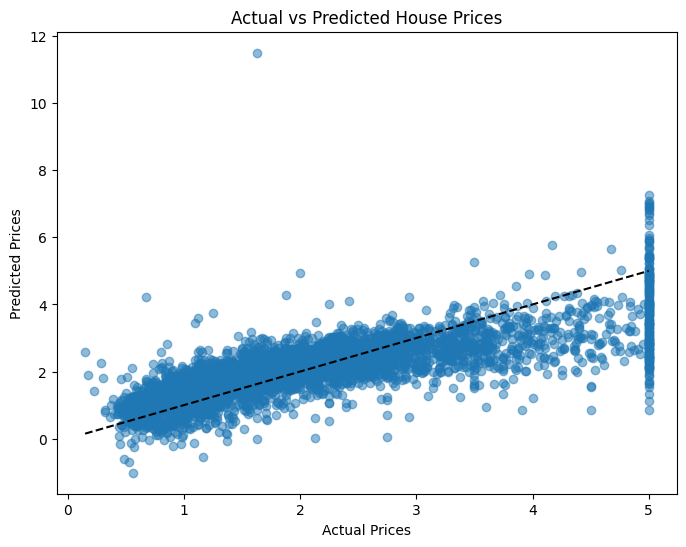

In [322]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()